<h1>Random graphs</h1>

<h3> Gabriele Cerioli, University of Trieste, 11/04/2026 </h3>

Loading Facebook network...
Network loaded: 4039 nodes, 88234 edges
Selecting a visually distant node pair and computing shortest path...
Computing spring layout (this may take ~30 seconds for 4k nodes)...
Selected nodes: 788 and 2899
Shortest path length: 5 steps
Plotting...


<Figure size 640x480 with 0 Axes>

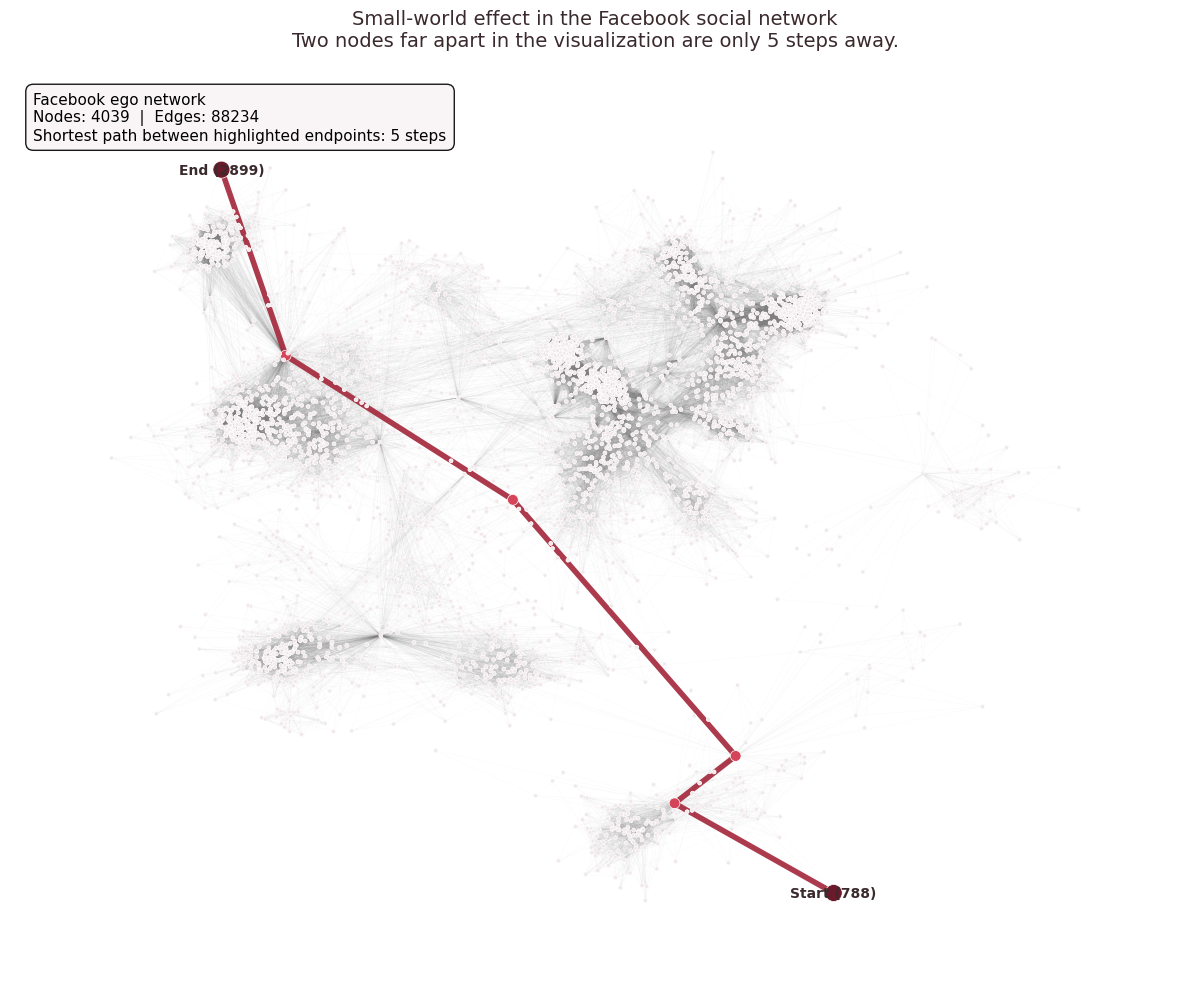

In [6]:
"""
Visual demonstration of the small‑world effect using the Facebook social network.
Two nodes placed far apart by the layout are connected by a very short path.
"""

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import gzip
import os
import tempfile

# ------------------------------
# Data loading (Facebook combined ego network)
# ------------------------------
def load_facebook_network():
    """Download and load the Facebook combined ego network from SNAP."""
    url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
    filename = "facebook_combined.txt.gz"
    path = os.path.join(tempfile.gettempdir(), filename)

    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, path)

    G = nx.Graph()
    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            u, v = map(int, line.strip().split())
            G.add_edge(u, v)
    return G

# ------------------------------
# Select a visually distant node pair based on spring layout
# ------------------------------
def select_distant_node_pair(G, layout_seed=42):
    """
    Compute a spring layout and pick two nodes with large Euclidean distance.
    Returns the graph, positions, source, target, path length, and path.
    """
    # The Facebook network is already connected
    print("Computing spring layout (this may take ~30 seconds for 4k nodes)...")
    pos = nx.spring_layout(G, seed=layout_seed, k=0.4, iterations=50)

    # Find the pair of nodes with maximum Euclidean distance in the layout
    max_dist = -1
    node_pair = (None, None)
    nodes_list = list(G.nodes())
    for i, u in enumerate(nodes_list):
        for v in nodes_list[i+1:]:
            d = np.linalg.norm(pos[u] - pos[v])
            if d > max_dist:
                max_dist = d
                node_pair = (u, v)

    u, v = node_pair
    path = nx.shortest_path(G, source=u, target=v)
    path_length = len(path) - 1

    return G, pos, u, v, path_length, path

# ------------------------------
# Plotting the highlighted shortest path
# ------------------------------
def plot_small_world_path(G, pos, source, target, path, path_length):
    """Draw the network with the shortest path highlighted."""
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')

    # Draw all edges very faintly in the background
    nx.draw_networkx_edges(G, pos, ax=ax,
                           alpha=0.05, edge_color='gray', width=0.3)

    # Draw all nodes with small, pale circles
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=8,
                           node_color='#E8C4CB',
                           edgecolors='none')

    # Highlight the edges of the shortest path
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edgelist=path_edges,
                           edge_color='#A3253A', width=4.0, alpha=0.9)

    # Color nodes: endpoints dark red, intermediate nodes medium red
    node_colors = []
    node_sizes = []
    for node in G.nodes():
        if node == source or node == target:
            node_colors.append('#6B1A2A')
            node_sizes.append(150)
        elif node in path:
            node_colors.append('#D4455A')
            node_sizes.append(60)
        else:
            node_colors.append('#F0E8EA')
            node_sizes.append(8)

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           edgecolors='white', linewidths=0.5)

    # Label the endpoints
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={source: f"Start ({source})",
                                    target: f"End ({target})"},
                            font_size=10, font_weight='bold',
                            font_color='#3B2A2D')

    # Annotation box with statistics
    ax.text(0.02, 0.98,
            f"Facebook ego network\n"
            f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}\n"
            f"Shortest path between highlighted endpoints: {path_length} steps",
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.5", fc="#F9F4F5", alpha=0.9))

    ax.set_title("Small‑world effect in the Facebook social network\n"
                 "Two nodes far apart in the visualization are only "
                 f"{path_length} steps away.",
                 fontsize=14, pad=20, color='#3B2A2D')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig("facebook_small_world_path.pdf", bbox_inches='tight', dpi=200)
    plt.show()

# ------------------------------
# Main
# ------------------------------
if __name__ == "__main__":
    print("Loading Facebook network...")
    G = load_facebook_network()
    print(f"Network loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    print("Selecting a visually distant node pair and computing shortest path...")
    G, pos, src, tgt, plen, path = select_distant_node_pair(G, layout_seed=42)

    print(f"Selected nodes: {src} and {tgt}")
    print(f"Shortest path length: {plen} steps")
    print("Plotting...")
    plt.savefig("small_world.pdf", bbox_inches='tight')
    plot_small_world_path(G, pos, src, tgt, path, plen)

<Figure size 640x480 with 0 Axes>

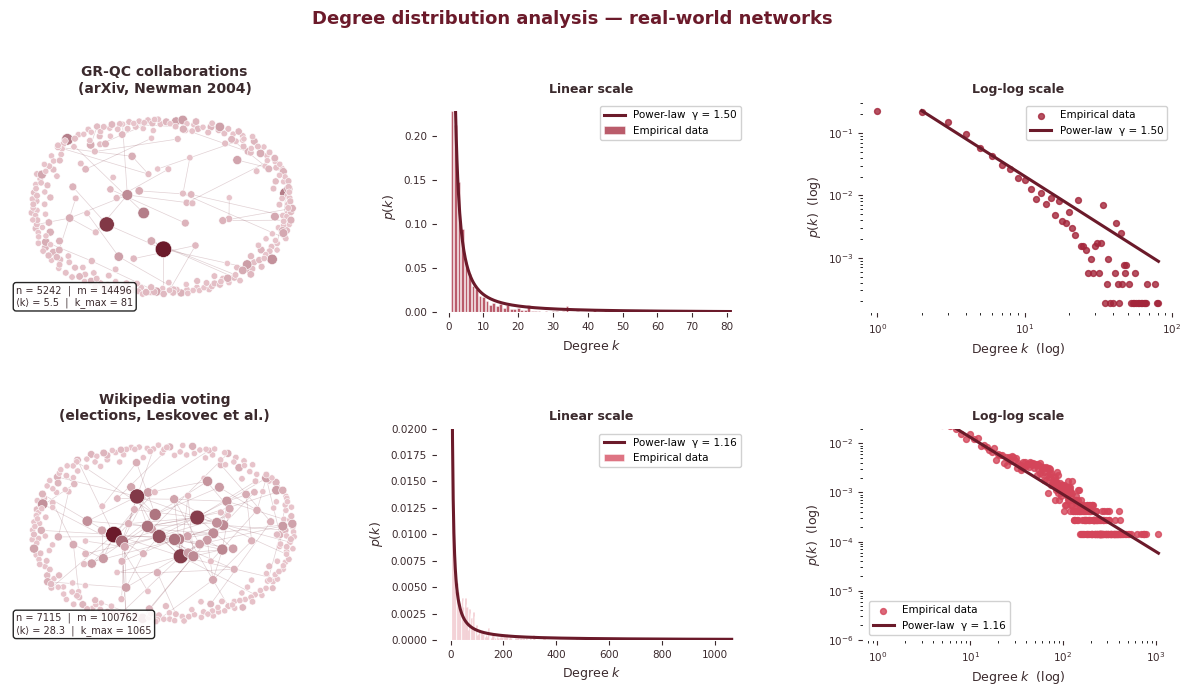

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from collections import Counter
import urllib.request, gzip, os, tempfile

SEED = 42

BORDEAUX  = "#6B1A2A"
BORDEAUX2 = "#A3253A"
BORDEAUX3 = "#D4455A"
DUST      = "#FFFFFF"
SLATE     = "#3B2A2D"

COLORS = {
    "grqc":      {"hist": BORDEAUX2, "pl": BORDEAUX},
    "wikivote":  {"hist": BORDEAUX3, "pl": BORDEAUX},
}

# ── Data loading ─────────────────────────────────────────────
def load_snap_graph(url, filename):
    path = os.path.join(tempfile.gettempdir(), filename)
    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, path)
    G = nx.Graph()
    opener = gzip.open if filename.endswith(".gz") else open
    with opener(path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            G.add_edge(int(parts[0]), int(parts[1]))
    return nx.Graph(G)  # force undirected (Wiki-Vote is directed originally)

# ── Fitting ──────────────────────────────────────────────────
def power_law(k, a, gamma):
    return a * k ** (-gamma)

def fit_power_law(degrees):
    counts = Counter(degrees)
    ks = np.array(sorted(counts), dtype=float)
    ps = np.array([counts[k] for k in ks], dtype=float) / len(degrees)
    mask = ks > 1
    ks, ps = ks[mask], ps[mask]
    try:
        popt, _ = curve_fit(power_law, ks, ps, p0=[1.0, 2.5], maxfev=10000)
    except RuntimeError:
        popt = [1.0, 2.5]
    return popt, ks, ps

# ── Plotting ─────────────────────────────────────────────────
def plot_all(networks):
    fig = plt.figure(figsize=(15, 7))
    fig.patch.set_facecolor("#FFFFFF")
    gs = gridspec.GridSpec(2, 3, figure=fig, wspace=0.38, hspace=0.55)

    for row, (name, (G, ck)) in enumerate(networks.items()):
        c = COLORS[ck]
        degs     = [d for _, d in G.degree()]
        deg_arr  = np.array(degs, dtype=float)
        deg_norm = (deg_arr - deg_arr.min()) / (deg_arr.max() - deg_arr.min() + 1e-9)

        # ── Col 0: graph visualization (subsample to 300 nodes) ──
        ax_g = fig.add_subplot(gs[row, 0])
        ax_g.set_facecolor("#FFFFFF")
        nodes = list(G.nodes())
        if len(nodes) > 300:
            rng    = np.random.default_rng(SEED)
            sample = set(rng.choice(nodes, 300, replace=False))
            Gv     = G.subgraph(sample)
        else:
            Gv = G
        dv      = np.array([G.degree(n) for n in Gv.nodes()], dtype=float)
        dv_norm = (dv - dv.min()) / (dv.max() - dv.min() + 1e-9)
        pos     = nx.spring_layout(Gv, seed=SEED, k=0.5)

        nx.draw_networkx_edges(Gv, pos, ax=ax_g,
                               alpha=0.2, width=0.5, edge_color=BORDEAUX)

        node_colors = [
            (
                (1 - t) * np.array([232/255, 196/255, 203/255]) +
                t       * np.array([ 107/255,  26/255,  42/255])
            )
            for t in dv_norm
        ]
        nx.draw_networkx_nodes(Gv, pos, ax=ax_g,
                               node_color=node_colors,
                               node_size=20 + 120 * dv_norm,
                               edgecolors="white", linewidths=0.4)
        ax_g.set_title(name, fontsize=10, fontweight="bold", pad=6, color=SLATE)
        ax_g.text(0.02, 0.02,
                  f"n = {G.number_of_nodes()}  |  m = {G.number_of_edges()}\n"
                  f"⟨k⟩ = {np.mean(deg_arr):.1f}  |  k_max = {int(deg_arr.max())}",
                  transform=ax_g.transAxes, fontsize=7, va="bottom", color=SLATE,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
        ax_g.axis("off")

        # ── Col 1: linear scale ──────────────────────────────
        ax_lin = fig.add_subplot(gs[row, 1])
        ax_lin.set_facecolor("#FFFFFF")
        counts_d = Counter(degs)
        ks_all   = np.array(sorted(counts_d), dtype=float)
        ps_all   = np.array([counts_d[k] for k in ks_all]) / len(degs)

        ax_lin.bar(ks_all, ps_all, color=c["hist"], alpha=0.75,
                   edgecolor="white", linewidth=0.4, label="Empirical data", zorder=2)

        popt, ks_fit, _ = fit_power_law(degs)
        k_sm = np.linspace(ks_fit.min(), ks_fit.max(), 400)
        ax_lin.plot(k_sm, power_law(k_sm, *popt),
                    color=c["pl"], lw=2.2,
                    label=f"Power-law  γ = {popt[1]:.2f}", zorder=3)

        ax_lin.set_xlabel("Degree $k$", fontsize=9, color=SLATE)
        ax_lin.set_ylabel("$p(k)$",     fontsize=9, color=SLATE)
        ax_lin.set_title("Linear scale", fontsize=9, fontweight="bold", color=SLATE)
        ax_lin.legend(fontsize=7.5, framealpha=0.9)
        ax_lin.tick_params(labelsize=7.5, colors=SLATE)
        ax_lin.spines[["top", "right"]].set_visible(False)
        ax_lin.spines[["left", "bottom"]].set_color(DUST)
        ax_lin.grid(axis="y", alpha=0.4, color=DUST, zorder=1)

        # For Wikipedia voting, limit y-axis to 0.10
        if ck == "wikivote":
            ax_lin.set_ylim(0, 0.02)

        # ── Col 2: log-log scale ─────────────────────────────
        ax_log = fig.add_subplot(gs[row, 2])
        ax_log.set_facecolor("#FFFFFF")
        mask_pos = ps_all > 0
        ax_log.scatter(ks_all[mask_pos], ps_all[mask_pos],
                       color=c["hist"], alpha=0.8, s=18,
                       label="Empirical data", zorder=2)
        ax_log.plot(k_sm, power_law(k_sm, *popt),
                    color=c["pl"], lw=2.2,
                    label=f"Power-law  γ = {popt[1]:.2f}", zorder=3)
        ax_log.set_xscale("log")
        ax_log.set_yscale("log")
        ax_log.set_xlabel("Degree $k$  (log)", fontsize=9, color=SLATE)
        ax_log.set_ylabel("$p(k)$  (log)",     fontsize=9, color=SLATE)
        ax_log.set_title("Log-log scale", fontsize=9, fontweight="bold", color=SLATE)
        ax_log.legend(fontsize=7.5, framealpha=0.9)
        ax_log.tick_params(labelsize=7.5, colors=SLATE)
        ax_log.spines[["top", "right"]].set_visible(False)
        ax_log.spines[["left", "bottom"]].set_color(DUST)
        ax_log.grid(alpha=0.3, which="both", color=DUST, zorder=1)

        # For Wikipedia voting, limit y-axis to 0.10 (top limit)
        if ck == "wikivote":
            ax_log.set_ylim(bottom=1e-6, top=0.02)  # keep positive bottom for log scale

    fig.suptitle("Degree distribution analysis — real-world networks",
                 fontsize=13, fontweight="bold", color=BORDEAUX, y=1.01)
    plt.savefig("degree_distributions.pdf", bbox_inches="tight", dpi=200)
    plt.show()

# ── Main ─────────────────────────────────────────────────────
if __name__ == "__main__":
    G_grqc    = load_snap_graph(
        "https://snap.stanford.edu/data/ca-GrQc.txt.gz", "ca-GrQc.txt.gz")
    G_wikivote = load_snap_graph(
        "https://snap.stanford.edu/data/wiki-Vote.txt.gz", "wiki-Vote.txt.gz")

    networks = {
        "GR-QC collaborations\n(arXiv, Newman 2004)":        (G_grqc,    "grqc"),
        "Wikipedia voting\n(elections, Leskovec et al.)":    (G_wikivote, "wikivote"),
    }
plt.savefig("degree_distributions.pdf", bbox_inches='tight')
plot_all(networks)

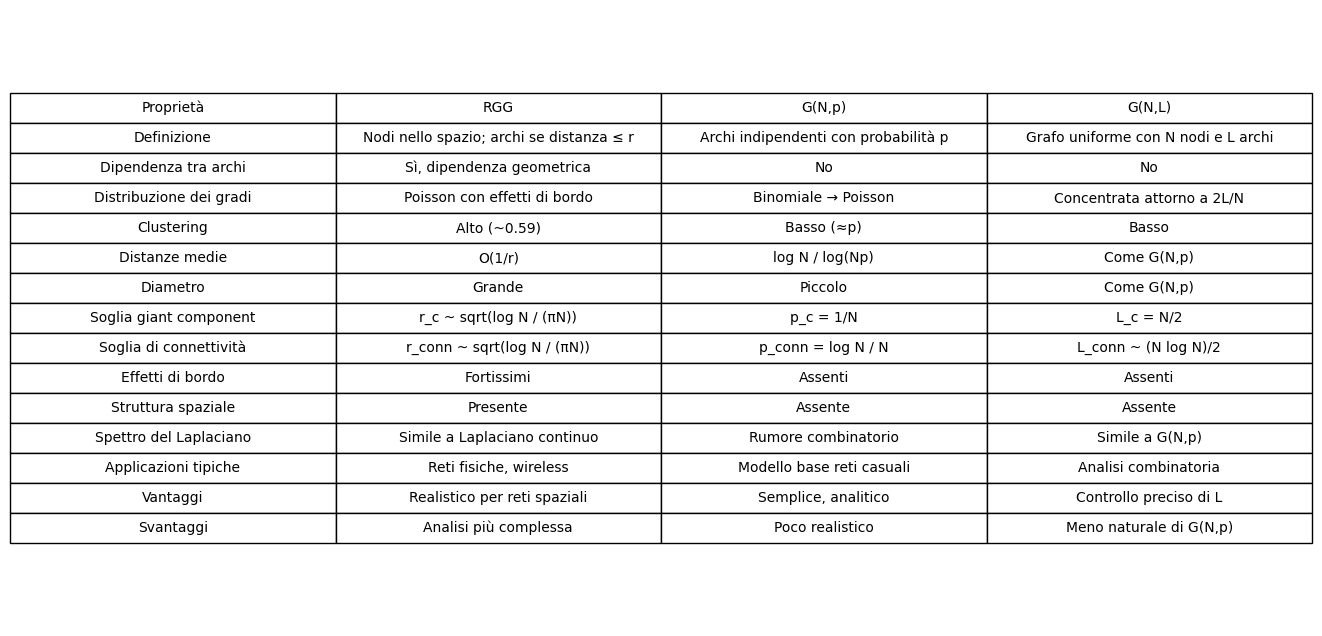

In [181]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for the table
data = {
    "Proprietà": [
        "Definizione",
        "Dipendenza tra archi",
        "Distribuzione dei gradi",
        "Clustering",
        "Distanze medie",
        "Diametro",
        "Soglia giant component",
        "Soglia di connettività",
        "Effetti di bordo",
        "Struttura spaziale",
        "Spettro del Laplaciano",
        "Applicazioni tipiche",
        "Vantaggi",
        "Svantaggi"
    ],
    "RGG": [
        "Nodi nello spazio; archi se distanza ≤ r",
        "Sì, dipendenza geometrica",
        "Poisson con effetti di bordo",
        "Alto (~0.59)",
        "O(1/r)",
        "Grande",
        "r_c ~ sqrt(log N / (πN))",
        "r_conn ~ sqrt(log N / (πN))",
        "Fortissimi",
        "Presente",
        "Simile a Laplaciano continuo",
        "Reti fisiche, wireless",
        "Realistico per reti spaziali",
        "Analisi più complessa"
    ],
    "G(N,p)": [
        "Archi indipendenti con probabilità p",
        "No",
        "Binomiale → Poisson",
        "Basso (≈p)",
        "log N / log(Np)",
        "Piccolo",
        "p_c = 1/N",
        "p_conn = log N / N",
        "Assenti",
        "Assente",
        "Rumore combinatorio",
        "Modello base reti casuali",
        "Semplice, analitico",
        "Poco realistico"
    ],
    "G(N,L)": [
        "Grafo uniforme con N nodi e L archi",
        "No",
        "Concentrata attorno a 2L/N",
        "Basso",
        "Come G(N,p)",
        "Come G(N,p)",
        "L_c = N/2",
        "L_conn ~ (N log N)/2",
        "Assenti",
        "Assente",
        "Simile a G(N,p)",
        "Analisi combinatoria",
        "Controllo preciso di L",
        "Meno naturale di G(N,p)"
    ]
}

df = pd.DataFrame(data)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Create table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Save image
plt.savefig("tabella_confronto_modelli.png", dpi=300, bbox_inches='tight')
plt.show()


<h2>Model G(N,L)</h2>

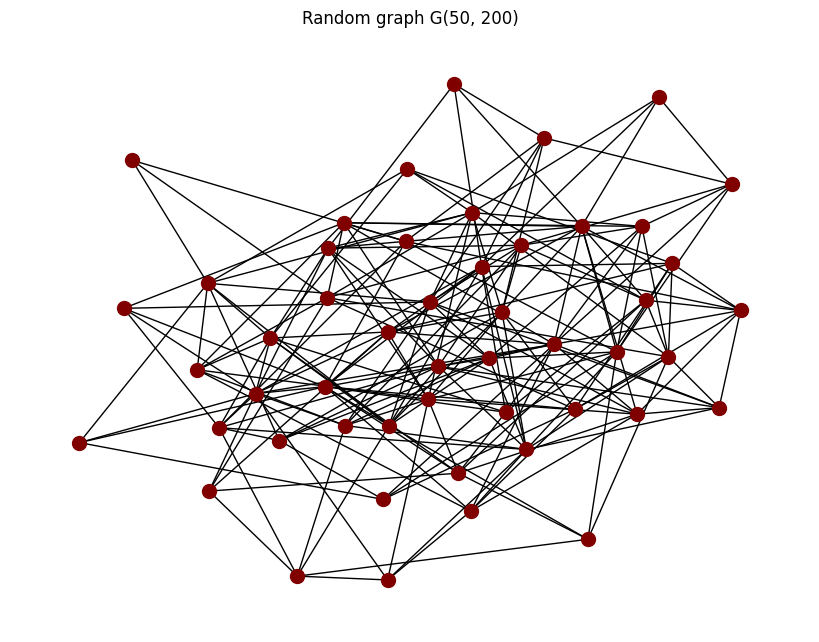

Numero di nodi: 50
Numero di archi: 200
Grado medio: 8.00


In [100]:
import networkx as nx
import matplotlib.pyplot as plt

# Parametri del grafo
N = 50  # Numero di nodi
L = 200  # Numero di archi

# Genera il grafo casuale G(N,L)
G = nx.gnm_random_graph(N, L)

# Visualizza il grafo
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=False, node_color='#800000', node_size=100, font_size=16, font_weight='bold')
plt.title(f'Random graph G({N}, {L})')
plt.show()

# Informazioni sul grafo
print(f"Numero di nodi: {G.number_of_nodes()}")
print(f"Numero di archi: {G.number_of_edges()}")
print(f"Grado medio: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")

<h2>Model G(N,p) Erdos-Renyi</h2>

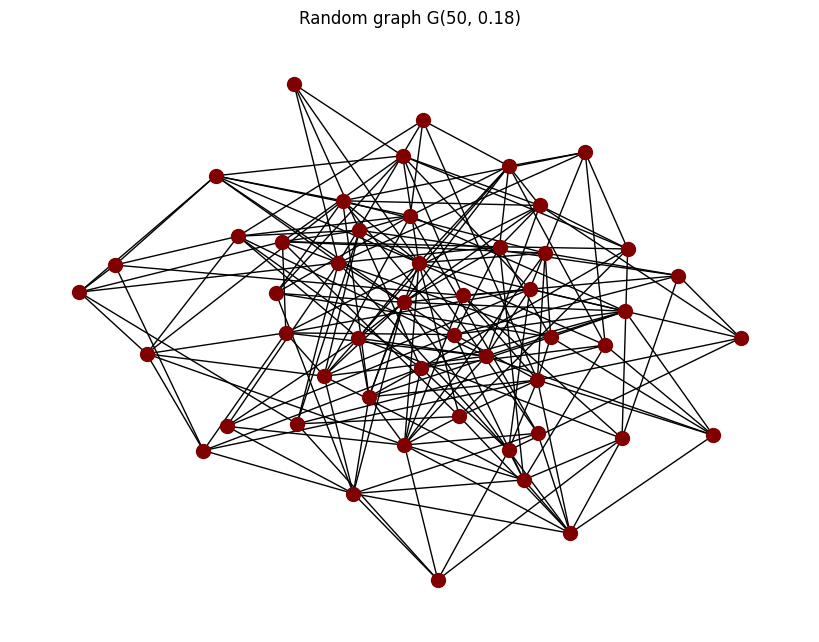

Number of nodes: 50
Number of links: 200
Average degree: 8.00


In [101]:
import networkx as nx
import matplotlib.pyplot as plt

# Graphs parameters
N = 50  # Number of nodes
p = 0.18  # Number of links

# Genera il grafo casuale G(N,p)
G = nx.erdos_renyi_graph(N, p)


plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=False, node_color='#800000', node_size=100, font_size=16, font_weight='bold')
plt.title(f'Random graph G({N}, {p})')
plt.show()

# Graph info
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of links: {G.number_of_edges()}")
print(f"Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")

<h2>Geometric random graph </h2>

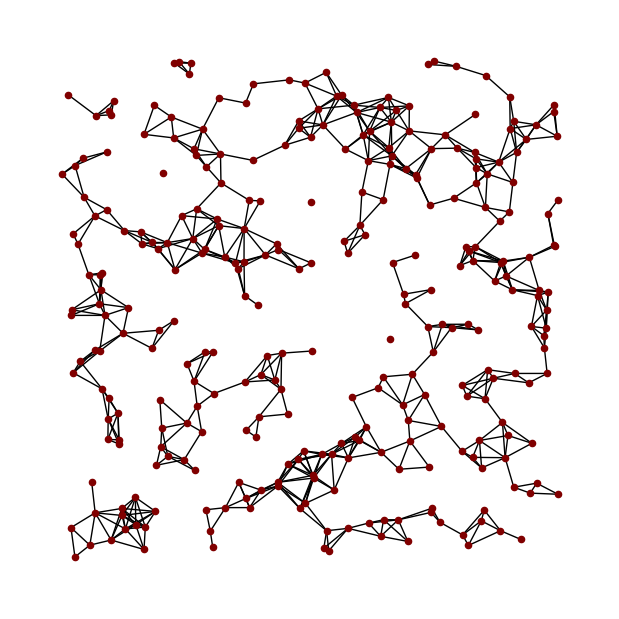

In [173]:
import numpy as np
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# Parameters
N=300 # Number of nodes
r=0.073 # Connection radius

#Generating N points in the unit square
points= np.random.rand(N,2)

#Computing the distance matrix
dist_matrix= squareform(pdist(points))

#Building the graph
G=nx.Graph()

for i, (x,y) in enumerate(points):
    G.add_node(i, pos=(x,y))

for i in range(N):
    for j in range (i+1,N):
        if dist_matrix[i,j]<=r:
            G.add_edge(i,j)

# Visualize the graph
pos = nx.get_node_attributes(G, 'pos')

plt.figure(figsize=(6, 6))
nx.draw(G, pos,node_color='#800000', node_size=20)
plt.show()


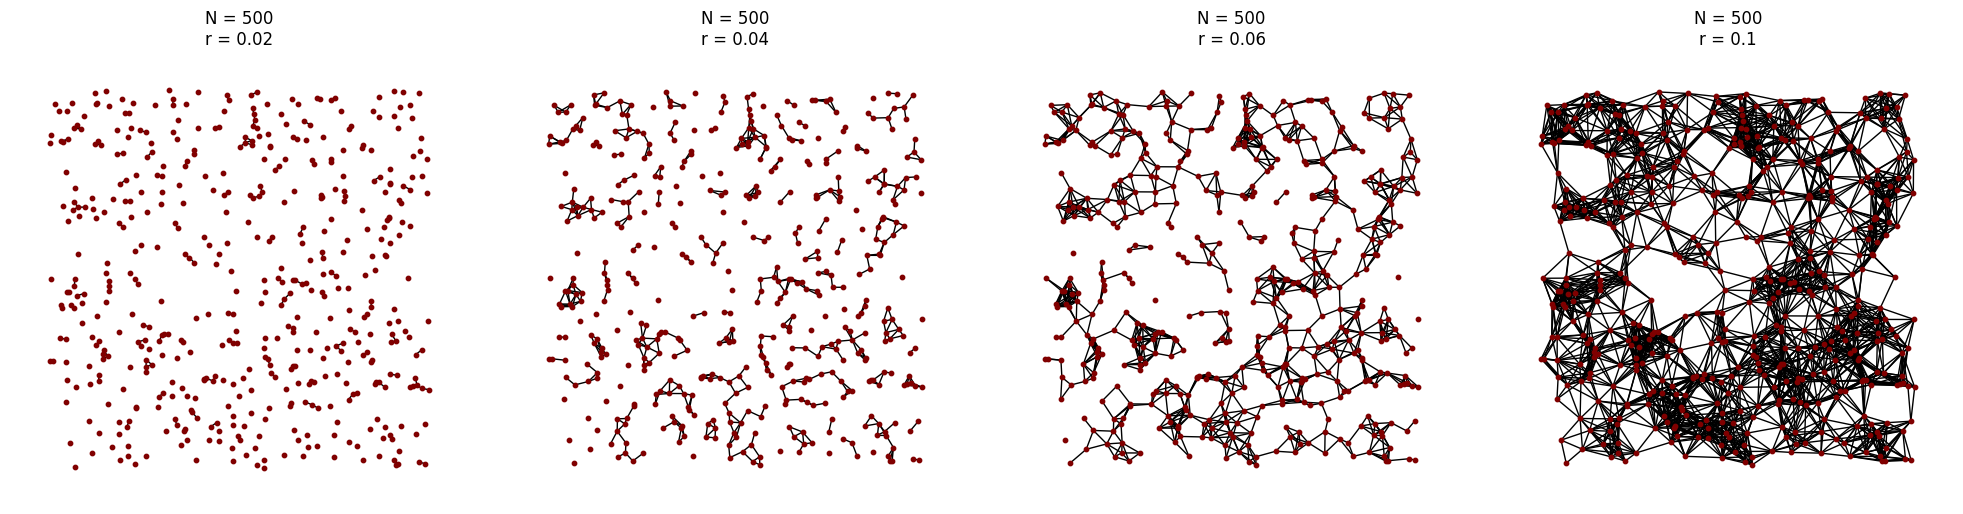

In [185]:
import numpy as np
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# Parameters
N = 500
r_values = [0.02, 0.04, 0.06, 0.10]   # radii you want to visualize

# Generate fixed points once
points = np.random.rand(N, 2)

# Compute distance matrix once
dist_matrix = squareform(pdist(points))

# Prepare figure
fig, axes = plt.subplots(1, len(r_values), figsize=(5 * len(r_values), 5))

# If only one r, axes is not a list
if len(r_values) == 1:
    axes = [axes]

for ax, r in zip(axes, r_values):

    # Build graph for this r
    G = nx.Graph()

    # Add nodes
    for i, (x, y) in enumerate(points):
        G.add_node(i, pos=(x, y))

    # Add edges
    for i in range(N):
        for j in range(i + 1, N):
            if dist_matrix[i, j] <= r:
                G.add_edge(i, j)

    # Extract positions
    pos = nx.get_node_attributes(G, 'pos')

    # Plot
    ax.set_title(f"N = {N}\nr = {r}")
    nx.draw(G, pos, node_size=10, node_color="#800000", ax=ax)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


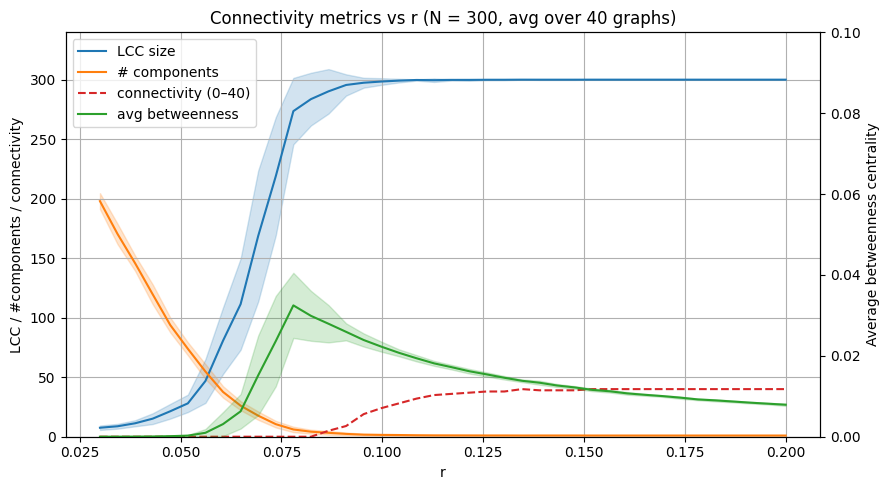

In [178]:
import numpy as np
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# Parameters
N = 300
r_values = np.linspace(0.03, 0.2, 40)
num_graphs_per_r = 40

def generate_rgg(N, r):
    points = np.random.rand(N, 2)
    dist_matrix = squareform(pdist(points))

    G = nx.Graph()
    for i, (x, y) in enumerate(points):
        G.add_node(i, pos=(x, y))

    for i in range(N):
        for j in range(i + 1, N):
            if dist_matrix[i, j] <= r:
                G.add_edge(i, j)
    return G

def graph_metrics(G):
    components = list(nx.connected_components(G))
    lcc_size = max(len(c) for c in components) if components else 0
    num_components = len(components)

    if len(G) > 0:
        bc = nx.betweenness_centrality(G)
        avg_bc = np.mean(list(bc.values()))
    else:
        avg_bc = 0.0

    return lcc_size, num_components, avg_bc

# Arrays for means and std dev
avg_LCC = []
avg_num_components = []
avg_avg_bc = []
connectivity_counts = []

std_LCC = []
std_num_components = []
std_avg_bc = []

for r in r_values:
    lcc_vals = []
    comp_vals = []
    bc_vals = []
    conn_count = 0

    for _ in range(num_graphs_per_r):
        G = generate_rgg(N, r)
        lcc_size, num_components, avg_bc = graph_metrics(G)

        lcc_vals.append(lcc_size)
        comp_vals.append(num_components)
        bc_vals.append(avg_bc)

        if nx.is_connected(G):
            conn_count += 1

    # Means
    avg_LCC.append(np.mean(lcc_vals))
    avg_num_components.append(np.mean(comp_vals))
    avg_avg_bc.append(np.mean(bc_vals))
    connectivity_counts.append(conn_count)

    # Standard deviations
    std_LCC.append(np.std(lcc_vals))
    std_num_components.append(np.std(comp_vals))
    std_avg_bc.append(np.std(bc_vals))

# Convert to arrays
avg_LCC = np.array(avg_LCC)
avg_num_components = np.array(avg_num_components)
avg_avg_bc = np.array(avg_avg_bc)
connectivity_counts = np.array(connectivity_counts)

std_LCC = np.array(std_LCC)
std_num_components = np.array(std_num_components)
std_avg_bc = np.array(std_avg_bc)

# Plot
fig, ax1 = plt.subplots(figsize=(9, 5))

# LCC + components + connectivity on left axis
ax1.plot(r_values, avg_LCC, label="LCC size", color="tab:blue")
ax1.fill_between(r_values, avg_LCC - std_LCC, avg_LCC + std_LCC,
                 color="tab:blue", alpha=0.2)

ax1.plot(r_values, avg_num_components, label="# components", color="tab:orange")
ax1.fill_between(r_values, avg_num_components - std_num_components,
                 avg_num_components + std_num_components,
                 color="tab:orange", alpha=0.2)

ax1.plot(r_values, connectivity_counts, label=f"connectivity (0–{num_graphs_per_r})",
         color="tab:red", linestyle="--")

ax1.set_xlabel("r")
ax1.set_ylabel("LCC / #components / connectivity")
ax1.set_ylim(0, max(np.max(avg_LCC + std_LCC),
                    np.max(avg_num_components + std_num_components),
                    num_graphs_per_r) * 1.1)
ax1.grid(True)

# Betweenness on right axis
ax2 = ax1.twinx()
ax2.plot(r_values, avg_avg_bc, label="avg betweenness", color="tab:green")
ax2.fill_between(r_values, avg_avg_bc - std_avg_bc, avg_avg_bc + std_avg_bc,
                 color="tab:green", alpha=0.2)
ax2.set_ylabel("Average betweenness centrality")
ax2.set_ylim(0, max(0.1, 1.1 * np.max(avg_avg_bc + std_avg_bc)))

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title(f"Connectivity metrics vs r (N = {N}, avg over {num_graphs_per_r} graphs)")
plt.tight_layout()
plt.show()
